# Chapter 7 — Orthogonality, Projection, and Least Squares

Chapter 5 ended with an impossible system: four data points, three unknowns, no
solution. Chapter 6 explained why no amount of inverting could help, since
$\mathbf{b}$ simply was not in the column space.

So change the question. If you cannot *reach* $\mathbf{b}$, reach the point of
the column space **closest** to it. That single move turns an unsolvable system
into a solvable one, and it is the most-used idea in applied mathematics: it is
linear regression, curve fitting, and the backbone of a great deal of
statistics.

Everything here rests on one geometric fact, and it is worth stating before any
formulas:

> The closest point in a subspace to $\mathbf{b}$ is the one whose **error
> vector is perpendicular to the subspace**. Perpendicularity is not an extra
> assumption. It is what "closest" *means*.

| Module | What you build | Data |
|---|---|---|
| I | The **dot product**: length, angle, and a surprise about high dimensions | — |
| II | **Projection** onto a line, and the projection matrix with $P^2 = P$ | — |
| III | Projection onto a subspace → the **normal equations**, derived not asserted | — |
| IV | **Least squares** in practice: a curve fit, and a digit classifier built from one solve | `ylecun/mnist` |
| V | **Gram–Schmidt and QR**, plus a measured reason never to use the normal equations | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU, with MNIST cached. Assumes Chapters 1–6.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — The Dot Product

## I.a One operation, three jobs

🧠 **The intuition.** Chapter 1 was emphatic that a vector space has only two
operations, and that there is no way to multiply two vectors. The dot product is
not a counterexample: it eats two vectors and returns a **number**, not a
vector. That extra structure is what brings *geometry*, meaning length, angle,
and perpendicularity, into a subject that until now had none.

📐 **The math.** For $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$:

$$ \mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^n u_i v_i = \mathbf{u}^\top \mathbf{v} $$

and from it:

$$ \|\mathbf{v}\| = \sqrt{\mathbf{v} \cdot \mathbf{v}}, \qquad
\cos\theta = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|\,\|\mathbf{v}\|}, \qquad
\mathbf{u} \perp \mathbf{v} \iff \mathbf{u} \cdot \mathbf{v} = 0 $$

The angle formula is guaranteed to make sense by the **Cauchy–Schwarz
inequality**, $|\mathbf{u}\cdot\mathbf{v}| \le \|\mathbf{u}\|\|\mathbf{v}\|$,
which keeps the ratio inside $[-1, 1]$ in every dimension.

💻 **The code.**

In [2]:
u = np.array([3.0, 1.0])
v = np.array([1.0, 2.0])

def angle_between(a, b):
    cos = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

print("u · v      =", u @ v)
print("||u||      =", np.linalg.norm(u), " = sqrt(u·u) =", np.sqrt(u @ u))
print("angle(u,v) =", round(angle_between(u, v), 2), "degrees")
print("\nperpendicular pair:", np.array([1.0, 0]) @ np.array([0, 1.0]), "-> dot product zero")

# Pythagoras is a statement about dot products
a, b_ = np.array([3.0, 0.0]), np.array([0.0, 4.0])
print(f"\n||a||^2 + ||b||^2 = {a@a + b_@b_:.0f}   ||a+b||^2 = {(a+b_)@(a+b_):.0f}"
      "   (equal only because a ⊥ b)")

# Cauchy-Schwarz, tested rather than assumed: |u·v| - ||u||·||v|| must never exceed 0
gap = max(abs(x @ y) - np.linalg.norm(x) * np.linalg.norm(y)
          for x, y in ((rng.normal(size=7), rng.normal(size=7)) for _ in range(5000)))
print(f"\nlargest |u·v| - ||u||·||v|| over 5000 random pairs: {gap:.3e}")
print("(Cauchy-Schwarz says this can never be positive, and it never was.)")

u · v      = 5.0
||u||      = 3.1622776601683795  = sqrt(u·u) = 3.1622776601683795
angle(u,v) = 45.0 degrees

perpendicular pair: 0.0 -> dot product zero

||a||^2 + ||b||^2 = 25   ||a+b||^2 = 25   (equal only because a ⊥ b)

largest |u·v| - ||u||·||v|| over 5000 random pairs: -2.318e-01
(Cauchy-Schwarz says this can never be positive, and it never was.)


## I.b A fact about high dimensions that is worth knowing

🧠 **The intuition.** In the plane, two random directions are usually at a
substantial angle. In $\mathbb{R}^{1000}$, two random directions are almost
always **nearly perpendicular**, with the typical angle concentrating hard
around 90°. There is simply an enormous amount of room to be unaligned in.

📐 **The math.** Take a random unit vector in $\mathbb{R}^n$: by symmetry each
of its $n$ coordinates carries the same expected share of the squared length,
so its squared component along any fixed direction averages $1/n$. For the
angle between two random directions,

$$ \mathbb{E}[\cos^2\theta] = \frac{1}{n}
\qquad\Longrightarrow\qquad
|\cos\theta| \sim \frac{1}{\sqrt{n}} $$

so the typical alignment decays like $1/\sqrt{n}$ and random directions crowd
toward 90° as the dimension grows.

💻 **The code.** Measure it.

 dimension   mean |cos angle|    mean angle   1/sqrt(n)
         2             0.6414         50.1°      0.7071
         3             0.4878         60.8°      0.5774
        10             0.2551         75.2°      0.3162
        50             0.1133         83.5°      0.1414
       200             0.0561         86.8°      0.0707
      1000             0.0247         88.6°      0.0316


      5000             0.0113         89.4°      0.0141


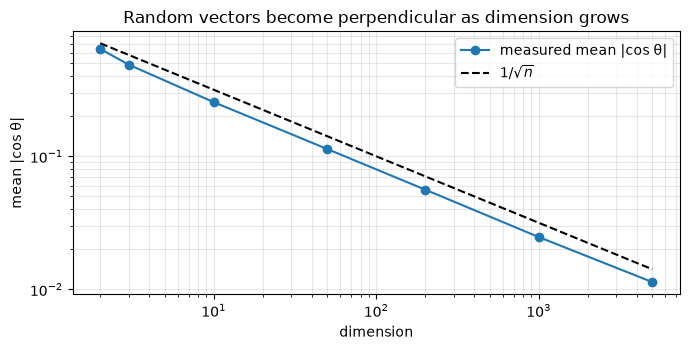

In [3]:
print(f"{'dimension':>10}  {'mean |cos angle|':>17}  {'mean angle':>12}  {'1/sqrt(n)':>10}")
dims, means = [], []
for n in [2, 3, 10, 50, 200, 1000, 5000]:
    X = rng.normal(size=(2000, n))
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    cos = np.abs(np.sum(X[::2] * X[1::2], axis=1))          # 1000 random pairs
    dims.append(n); means.append(cos.mean())
    print(f"{n:>10}  {cos.mean():>17.4f}  {np.degrees(np.arccos(cos.mean())):>11.1f}°  {1/np.sqrt(n):>10.4f}")

plt.figure(figsize=(7, 3.6))
plt.loglog(dims, means, "o-", label="measured mean |cos θ|")
plt.loglog(dims, [1 / np.sqrt(n) for n in dims], "k--", label=r"$1/\sqrt{n}$")
plt.xlabel("dimension"); plt.ylabel("mean |cos θ|"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("Random vectors become perpendicular as dimension grows")
plt.tight_layout(); plt.show()

The measurement tracks $1/\sqrt{n}$ closely. In 5,000 dimensions two random
directions are within a couple of degrees of perpendicular, which is why
high-dimensional data can carry so much independent information, and also why
"these two vectors are nearly orthogonal" is evidence of almost nothing unless
you compare it against this baseline.

---
# Module II — Projection Onto a Line

## II.a The shadow of a vector

🧠 **The intuition.** Shine a light straight down onto the line through
$\mathbf{a}$. The shadow of $\mathbf{b}$ is its **projection** $\mathbf{p}$, the
point of the line closest to $\mathbf{b}$. The leftover $\mathbf{e} =
\mathbf{b} - \mathbf{p}$ is the **error**, and it is perpendicular to the line.
That perpendicularity is not an observation about the picture; it is the
condition that *determines* $\mathbf{p}$.

📐 **The math.** Write $\mathbf{p} = \hat{x}\mathbf{a}$ and demand
$\mathbf{a} \cdot (\mathbf{b} - \hat{x}\mathbf{a}) = 0$. Solve for $\hat{x}$:

$$ \hat{x} = \frac{\mathbf{a}^\top \mathbf{b}}{\mathbf{a}^\top \mathbf{a}},
\qquad \mathbf{p} = \mathbf{a}\,\frac{\mathbf{a}^\top \mathbf{b}}{\mathbf{a}^\top \mathbf{a}}
= \underbrace{\frac{\mathbf{a}\mathbf{a}^\top}{\mathbf{a}^\top \mathbf{a}}}_{P} \mathbf{b} $$

Note the shape of $P$: $\mathbf{a}\mathbf{a}^\top$ is an *outer* product, an
$n \times n$ matrix of rank 1, while $\mathbf{a}^\top\mathbf{a}$ is a scalar.
Projection is a linear transformation, so of course it has a matrix.

💻 **The code.**

projection p = [1.8 0.6]    via matrix P @ b = [1.8 0.6]
error e = b - p = [-0.8  2.4]
e · a = -0.0  -> the error is perpendicular to the line

P =
 [[0.9 0.3]
 [0.3 0.1]]
P is symmetric: True
P @ P == P (projecting twice changes nothing): True
rank of P: 1  -> it flattens the plane onto one line


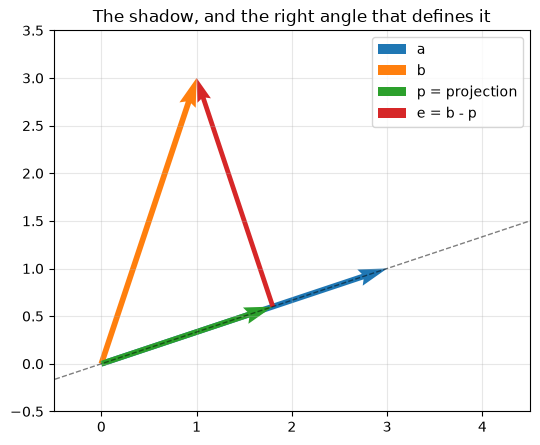

In [4]:
def project_onto_line(a, b):
    """Projection of b onto the line spanned by a."""
    return a * (a @ b) / (a @ a)

a = np.array([3.0, 1.0])
b = np.array([1.0, 3.0])
p = project_onto_line(a, b)
e = b - p

P = np.outer(a, a) / (a @ a)
print("projection p =", np.round(p, 4), "   via matrix P @ b =", np.round(P @ b, 4))
print("error e = b - p =", np.round(e, 4))
print("e · a =", round(e @ a, 12), " -> the error is perpendicular to the line")
print("\nP =\n", P)
print("P is symmetric:", np.allclose(P, P.T))
print("P @ P == P (projecting twice changes nothing):", np.allclose(P @ P, P))
print("rank of P:", np.linalg.matrix_rank(P), " -> it flattens the plane onto one line")

fig, ax = plt.subplots(figsize=(5.5, 5))
for vec, col, lab in [(a, "tab:blue", "a"), (b, "tab:orange", "b"), (p, "tab:green", "p = projection")]:
    ax.quiver(0, 0, *vec, angles="xy", scale_units="xy", scale=1, color=col, width=0.012, label=lab)
ax.plot([-1, 4.5], [-1/3, 1.5], "k--", lw=1, alpha=0.5)
ax.quiver(*p, *e, angles="xy", scale_units="xy", scale=1, color="tab:red", width=0.010, label="e = b - p")
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5); ax.set_aspect("equal")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("The shadow, and the right angle that defines it")
plt.tight_layout(); plt.show()

$P^2 = P$ deserves a moment. Projecting a shadow again does nothing, because the
shadow is already on the line. Any matrix satisfying $P^2 = P$ is called
**idempotent**, and together with symmetry that is precisely what makes a matrix
an orthogonal projection.

---
# Module III — Projection Onto a Subspace, and the Normal Equations

## III.a The same derivation, one dimension up

🧠 **The intuition.** Replace the line with the column space of a matrix $A$.
We want the combination of columns closest to $\mathbf{b}$, which is to say the
$\hat{\mathbf{x}}$ making $A\hat{\mathbf{x}}$ as close to $\mathbf{b}$ as
possible. Same condition as before: the error must be perpendicular to
*everything* in the subspace, which means perpendicular to every column of $A$.

📐 **The math.** "Perpendicular to every column" is exactly $A^\top(\mathbf{b} -
A\hat{\mathbf{x}}) = \mathbf{0}$, which rearranges to the **normal equations**:

$$ \boxed{\;A^\top A\,\hat{\mathbf{x}} = A^\top \mathbf{b}\;} $$

and, when $A$ has independent columns so that $A^\top A$ is invertible,

$$ \hat{\mathbf{x}} = (A^\top A)^{-1}A^\top \mathbf{b}, \qquad
\mathbf{p} = \underbrace{A(A^\top A)^{-1}A^\top}_{P}\,\mathbf{b} $$

Every regression formula you have ever seen is that boxed line. Note where it
came from: not from calculus, not from statistics, but from demanding a right
angle.

Note also what the error condition says in Chapter 5's language: the residual
lies in the **left null space** $N(A^\top)$, the orthogonal complement of the
column space. The four subspaces were not bookkeeping.

💻 **The code.**

In [5]:
def project_onto_subspace(A, b):
    """Least-squares projection of b onto the column space of A."""
    xhat = np.linalg.solve(A.T @ A, A.T @ b)        # the normal equations
    return A @ xhat, xhat

A = np.column_stack([np.array([1.0, 1.0, 0.0]),
                     np.array([0.0, 1.0, 1.0])])    # a plane in R^3
b = np.array([1.0, 2.0, 4.0])

p, xhat = project_onto_subspace(A, b)
e = b - p

print("b =", b, "\np =", np.round(p, 4), "  (the closest point of the plane)")
print("e = b - p =", np.round(e, 4))
print("\ne is perpendicular to BOTH columns:", np.round(A.T @ e, 12))
print("distance from b to the plane:", round(np.linalg.norm(e), 4))

P = A @ np.linalg.inv(A.T @ A) @ A.T
print("\nP symmetric:", np.allclose(P, P.T), "  P@P == P:", np.allclose(P @ P, P),
      "  rank(P):", np.linalg.matrix_rank(P))

# no other point of the plane is closer: check against random competitors
comp = A @ rng.normal(size=(2, 20000))
print("closest random competitor:", round(np.min(np.linalg.norm(comp - b[:, None], axis=0)), 4),
      "  vs the projection:", round(np.linalg.norm(e), 4))

b = [1. 2. 4.] 
p = [0. 3. 3.]   (the closest point of the plane)
e = b - p = [ 1. -1.  1.]

e is perpendicular to BOTH columns: [0. 0.]
distance from b to the plane: 1.7321

P symmetric: True   P@P == P: True   rank(P): 2
closest random competitor: 1.743   vs the projection: 1.7321


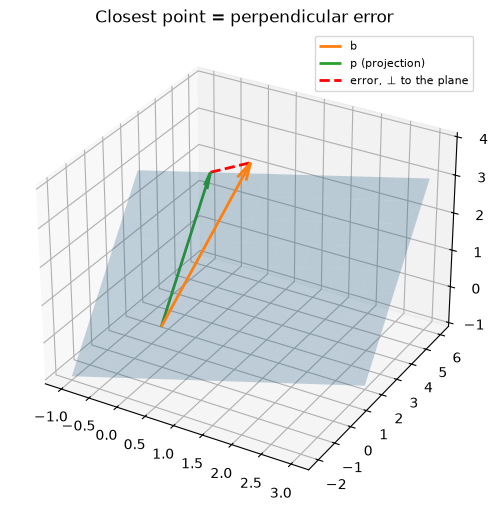

In [6]:
fig = plt.figure(figsize=(6.5, 5.2))
ax = fig.add_subplot(projection="3d")
s = np.linspace(-1, 3, 10)
S, T = np.meshgrid(s, s)
Pl = S[..., None] * A[:, 0] + T[..., None] * A[:, 1]
ax.plot_surface(Pl[..., 0], Pl[..., 1], Pl[..., 2], alpha=0.25, color="tab:blue")
ax.quiver(0, 0, 0, *b, color="tab:orange", arrow_length_ratio=0.1, lw=2, label="b")
ax.quiver(0, 0, 0, *p, color="tab:green", arrow_length_ratio=0.1, lw=2, label="p (projection)")
ax.plot(*np.column_stack([p, b]), "r--", lw=2, label="error, ⊥ to the plane")
ax.legend(fontsize=8); ax.set_title("Closest point = perpendicular error")
plt.tight_layout(); plt.show()

---
# Module IV — Least Squares in Practice

## IV.a Fitting a curve to noisy data

🧠 **The intuition.** Ten data points, three unknown coefficients. The system
is overdetermined and inconsistent, exactly the situation from Chapter 5, now
with a tool for it. Solving the normal equations
gives the parabola minimising the total squared vertical distance.

📐 **The math.** Minimising $\|A\mathbf{c} - \mathbf{y}\|^2$ over $\mathbf{c}$ is
the *same problem* as projecting $\mathbf{y}$ onto $C(A)$, because
$A\mathbf{c}$ ranges over exactly the column space as $\mathbf{c}$ ranges over
everything. "Least squares" and "orthogonal projection" are two names for one
computation.

💻 **The code.**

true coefficients   : [ 1.   -0.5   0.75]
least-squares fit   : [ 0.743 -0.385  0.842]
np.linalg.lstsq     : [ 0.743 -0.385  0.842]

sum of squared residuals: 5.7047
residual ⊥ every column of A: [-0. -0.  0.]


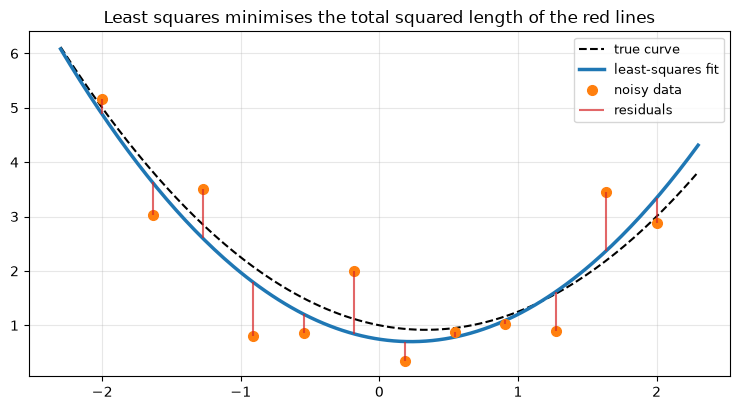

In [7]:
n_pts = 12
x_data = np.linspace(-2, 2, n_pts)
true_c = np.array([1.0, -0.5, 0.75])                     # 1 - 0.5x + 0.75x^2
y_data = np.vander(x_data, 3, increasing=True) @ true_c + rng.normal(scale=0.8, size=n_pts)

Av = np.vander(x_data, 3, increasing=True)               # 12 x 3: overdetermined
c_hat = np.linalg.solve(Av.T @ Av, Av.T @ y_data)        # normal equations
resid = Av @ c_hat - y_data

print("true coefficients   :", true_c)
print("least-squares fit   :", np.round(c_hat, 3))
print("np.linalg.lstsq     :", np.round(np.linalg.lstsq(Av, y_data, rcond=None)[0], 3))
print(f"\nsum of squared residuals: {resid @ resid:.4f}")
print("residual ⊥ every column of A:", np.round(Av.T @ resid, 10))

grid = np.linspace(-2.3, 2.3, 200)
plt.figure(figsize=(7.5, 4.2))
plt.plot(grid, np.vander(grid, 3, increasing=True) @ true_c, "k--", lw=1.5, label="true curve")
plt.plot(grid, np.vander(grid, 3, increasing=True) @ c_hat, lw=2.5, label="least-squares fit")
plt.plot(x_data, y_data, "o", ms=7, label="noisy data")
plt.vlines(x_data, y_data, Av @ c_hat, color="tab:red", lw=1.5, alpha=0.7, label="residuals")
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.title("Least squares minimises the total squared length of the red lines")
plt.tight_layout(); plt.show()

The printed line `residual ⊥ every column of A` is the whole chapter in one
check. The fit is not "the line that looks best". It is the unique choice that
leaves an error perpendicular to everything you were allowed to build.

## IV.b A classifier from one solve

💻 **The code.** Least squares does not care that the columns came from a
polynomial. Feed it 784 pixel columns and ask for a label: $-1$ for a 3, $+1$
for an 8. The solution is the linear map minimising squared error, and its sign
is a working classifier, trained by solving one linear system, with no
iteration of any kind.

In [8]:
from datasets import load_dataset

mnist = load_dataset("ylecun/mnist")
N_TRAIN = 4000          # <- knob

def digit_matrix(split, digits=(3, 8), n=None):
    labels = np.array(split["label"])
    idx = np.flatnonzero(np.isin(labels, digits))
    if n:
        idx = idx[:n]
    imgs = np.stack([np.array(im, dtype=np.float64) for im in split.select(idx)["image"]])
    X = imgs.reshape(len(idx), -1) / 255.0
    X = np.column_stack([X, np.ones(len(idx))])          # bias column: the affine trick
    y = np.where(labels[idx] == digits[0], -1.0, 1.0)
    return X, y

X_tr, y_tr = digit_matrix(mnist["train"], n=N_TRAIN)
X_te, y_te = digit_matrix(mnist["test"])
print("training matrix:", X_tr.shape, " test:", X_te.shape)

# ridge-free normal equations, with a whisper of regularisation for stability
w = np.linalg.solve(X_tr.T @ X_tr + 1e-6 * np.eye(X_tr.shape[1]), X_tr.T @ y_tr)

for name, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
    acc = np.mean(np.sign(X @ w) == y)
    print(f"{name} accuracy: {acc:.3%}")

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


training matrix: (4000, 785)  test: (1984, 785)


train accuracy: 97.825%
test accuracy: 95.060%


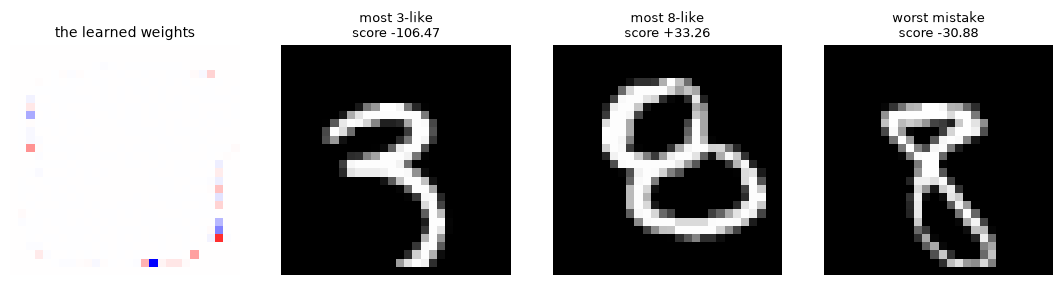

Red pixels push the score toward 8, blue toward 3. The weight vector is
readable as a picture, because each coordinate multiplies one pixel.


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
axes[0].imshow(w[:-1].reshape(28, 28), cmap="bwr",
               vmin=-np.abs(w[:-1]).max(), vmax=np.abs(w[:-1]).max())
axes[0].set_title("the learned weights", fontsize=10); axes[0].axis("off")

scores = X_te @ w
for ax, (idx, lab) in zip(axes[1:], [(np.argmin(scores), "most 3-like"),
                                     (np.argmax(scores), "most 8-like"),
                                     (int(np.argmax((np.sign(scores) != y_te) * np.abs(scores))), "worst mistake")]):
    ax.imshow(X_te[idx, :-1].reshape(28, 28), cmap="gray")
    ax.set_title(f"{lab}\nscore {scores[idx]:+.2f}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

print("Red pixels push the score toward 8, blue toward 3. The weight vector is")
print("readable as a picture, because each coordinate multiplies one pixel.")

About 95% test accuracy from a single call to `solve`. The point is not that
this is a good digit classifier. It is that "fit a linear model" and "project
onto a column space" are the same act, and the whole of it is one line of linear
algebra you derived from a right angle.

---
# Module V — Orthonormal Bases, Gram–Schmidt, and a Warning

## V.a Why orthonormal bases are worth building

🧠 **The intuition.** Chapter 3 measured the payoff: with an orthonormal basis,
coordinates are dot products instead of a linear solve, because the inverse is
just the transpose. Projection gets equally cheap: projecting onto the column
space of an orthonormal basis takes one multiplication by the basis and one by
its transpose, no inversion anywhere.

📐 **The math.** For orthonormal $Q$, $Q^\top Q = I$, so $Q^{-1} = Q^\top$: the
coordinates of $\mathbf{x}$ are $Q^\top \mathbf{x}$, and the projector onto the
column space is $QQ^\top$. **Gram–Schmidt** manufactures such a basis: take each
vector in turn, subtract off its projection onto everything already accepted, and
normalise what is left.

$$ \mathbf{q}_k = \frac{\mathbf{v}_k - \sum_{j<k} (\mathbf{q}_j^\top \mathbf{v}_k)\,\mathbf{q}_j}
{\left\| \mathbf{v}_k - \sum_{j<k} (\mathbf{q}_j^\top \mathbf{v}_k)\,\mathbf{q}_j \right\|} $$

Collecting the coefficients gives the **QR factorisation** $A = QR$, with $Q$
orthonormal and $R$ upper triangular.

💻 **The code.** Two versions, algebraically identical and numerically nothing
alike: *classical* Gram–Schmidt subtracts all projections against the original
vector, while *modified* Gram–Schmidt subtracts them one at a time, against the
partially-corrected vector.

In [10]:
def gram_schmidt(A, modified=False):
    """Orthonormalise the columns of A. Returns Q."""
    A = np.array(A, dtype=float)
    Q = np.zeros_like(A)
    for k in range(A.shape[1]):
        v = A[:, k].copy()
        if modified:
            for j in range(k):
                v -= (Q[:, j] @ v) * Q[:, j]          # against the running remainder
        else:
            v -= Q[:, :k] @ (Q[:, :k].T @ A[:, k])    # all at once, against the original
        Q[:, k] = v / np.linalg.norm(v)
    return Q

M = np.column_stack([np.array([1.0, 1.0, 0.0]), np.array([1.0, 0.0, 1.0]),
                     np.array([0.0, 1.0, 1.0])])
Q = gram_schmidt(M)
print("Q =\n", Q)
print("\nQ^T Q = I:", np.allclose(Q.T @ Q, np.eye(3)))
print("same span as the original columns:",
      np.linalg.matrix_rank(np.column_stack([Q, M])) == 3)

# projection onto the span of the first two columns, two ways
b3 = np.array([1.0, 2.0, 4.0])
Q2, A2 = Q[:, :2], M[:, :2]
print("\nprojection via Q Q^T   :", np.round(Q2 @ (Q2.T @ b3), 6))
print("projection via A(A^TA)^-1A^T:", np.round(A2 @ np.linalg.solve(A2.T @ A2, A2.T @ b3), 6))

Q =
 [[ 0.707  0.408 -0.577]
 [ 0.707 -0.408  0.577]
 [ 0.     0.816  0.577]]

Q^T Q = I: True
same span as the original columns: True

projection via Q Q^T   : [2.667 0.333 2.333]
projection via A(A^TA)^-1A^T: [2.667 0.333 2.333]


In [11]:
# a matrix whose columns are nearly parallel: the stress test
def hilbert(n):
    i = np.arange(1, n + 1)
    return 1.0 / (i[:, None] + i[None, :] - 1)

print(f"{'n':>3} {'cond(H)':>10} {'classical GS':>16} {'modified GS':>14} {'np.linalg.qr':>14}")
for n in [6, 8, 10, 12]:
    H = hilbert(n)
    loss = lambda Qm: np.linalg.norm(Qm.T @ Qm - np.eye(n))
    print(f"{n:>3} {np.linalg.cond(H):>10.1e} {loss(gram_schmidt(H)):>16.2e} "
          f"{loss(gram_schmidt(H, modified=True)):>14.2e} {loss(np.linalg.qr(H)[0]):>14.2e}")

print("\nThe last three columns measure how far Q^T Q strays from the identity,")
print("which is how badly the 'orthonormal' basis has stopped being orthonormal.")
print("Same formula, different order of operations, and at n=8 classical Gram-Schmidt")
print("has already produced a Q whose columns are not remotely perpendicular.")

  n    cond(H)     classical GS    modified GS   np.linalg.qr
  6    1.5e+07         3.77e-04       1.01e-09       8.60e-16
  8    1.5e+10         1.43e+00       3.62e-07       7.33e-16
 10    1.6e+13         3.47e+00       2.48e-04       1.40e-15
 12    1.6e+16         5.48e+00       1.61e-01       1.72e-15

The last three columns measure how far Q^T Q strays from the identity,
which is how badly the 'orthonormal' basis has stopped being orthonormal.
Same formula, different order of operations, and at n=8 classical Gram-Schmidt
has already produced a Q whose columns are not remotely perpendicular.


## V.b Why not to use the normal equations you just derived

🧠 **The intuition.** The normal equations are a beautiful piece of theory and a
liability in floating point, because multiplying a matrix by its own transpose
**squares the condition number**. A matrix you could just about handle becomes
one you cannot. Solving via QR avoids ever forming that product.

📐 **The math.** The danger is exact: $\kappa(A^\top A) = \kappa(A)^2$. QR
sidesteps it. From $A = QR$ and $Q^\top Q = I$:

$$ A^\top A \hat{\mathbf{x}} = A^\top \mathbf{b}
\;\Longrightarrow\; R^\top Q^\top Q R \hat{\mathbf{x}} = R^\top Q^\top \mathbf{b}
\;\Longrightarrow\; R\hat{\mathbf{x}} = Q^\top \mathbf{b} $$

a triangular system, solved by back-substitution, with the conditioning of $A$
rather than of $A^\top A$.

💻 **The code.** Fit a high-degree polynomial, a famously ill-conditioned design
matrix, both ways, and compare against the true coefficients.

In [12]:
deg = 14                                   # <- knob: polynomial degree
xs = np.linspace(0, 1, 60)
true = rng.normal(size=deg + 1)
ys = np.vander(xs, deg + 1, increasing=True) @ true

Ades = np.vander(xs, deg + 1, increasing=True)
print(f"cond(A)     = {np.linalg.cond(Ades):.2e}")
print(f"cond(A^T A) = {np.linalg.cond(Ades.T @ Ades):.2e}   <- squared, as predicted")

c_normal = np.linalg.solve(Ades.T @ Ades, Ades.T @ ys)
Qq, Rr = np.linalg.qr(Ades)
c_qr = np.linalg.solve(Rr, Qq.T @ ys)
c_lstsq = np.linalg.lstsq(Ades, ys, rcond=None)[0]

for name, c in [("normal equations", c_normal), ("QR", c_qr), ("np.linalg.lstsq (SVD)", c_lstsq)]:
    err = np.linalg.norm(c - true) / np.linalg.norm(true)
    print(f"{name:<24} relative coefficient error: {err:.2e}")

cond(A)     = 2.28e+10
cond(A^T A) = 1.78e+18   <- squared, as predicted
normal equations         relative coefficient error: 1.48e+00
QR                       relative coefficient error: 1.73e-07
np.linalg.lstsq (SVD)    relative coefficient error: 1.85e-07


The normal equations lose a large chunk of the available precision on this
problem; $QR$ keeps most of it. This is the standard practice behind every
serious least-squares routine, and it is why `np.linalg.lstsq` does **not**
implement the formula that textbooks (and this notebook, in Module III) derive. It
uses the SVD, which is even more robust, and which Chapter 9 builds.

Derive with $A^\top A$. Compute with $QR$.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Dot product → length, angle, perpendicularity | One number-valued operation is what brings geometry into a vector space |
| Mean $\lvert\cos\theta\rvert \approx 1/\sqrt{n}$ | In high dimensions random vectors are nearly perpendicular, so know the baseline before you are impressed by one |
| $\mathbf{p} = \mathbf{a}(\mathbf{a}^\top\mathbf{b})/(\mathbf{a}^\top\mathbf{a})$, $P^2 = P$ | Projection is linear, idempotent, and symmetric, and it is defined by a right angle rather than by a formula |
| $A^\top A\hat{\mathbf{x}} = A^\top\mathbf{b}$ | The normal equations *are* "error ⊥ column space", rearranged. Regression is geometry |
| A curve fit whose residual is ⊥ every column | Least squares = projection onto the column space. Two names, one computation |
| A 95%-accurate digit classifier from one `solve` | The same three lines scale from 3 columns to 785 without changing |
| Classical vs modified Gram–Schmidt | Algebraically identical, numerically not. Order of operations is part of the algorithm |
| $\kappa(A^\top A) = \kappa(A)^2$ | Derive with the normal equations; **compute** with $QR$ |

**Where the course goes from here.** Two chapters remain, and both ask the same
new question. So far we have taken the basis as given and studied what a matrix
does in it. Now turn it around: **is there a basis in which this particular
matrix becomes simple?**

**Chapter 8** answers it for square matrices, by finding the directions a matrix
merely *stretches* rather than rotates, its **eigenvectors**, and shows that in
that basis the matrix becomes diagonal, making powers and dynamics trivial.

**Chapter 9** answers it for *every* matrix, square or not, with the **singular
value decomposition**, and closes the loop on Chapter 3's compression
experiment by computing, from data, the best basis there is.